
<span style="font-size: 32px; font-weight: bold; color: #003366;">Proyecto Ausentismo en la administración pública de una provincia argentina</span>

<span style="font-size: 24px; font-weight: bold; color: #003366;">Variables Objetivo (Target Variables)</span>

* Predicción de Reincidencia / Ausentismo Frecuente: Clasificar si un agente superará determinado umbral de días o licencias en el próximo período (ej. alto riesgo de ausentismo).

* Tipificación de Ausencia (Salud vs. Administrativa): Predecir si una solicitud de ausencia será por motivos de salud basándose en el perfil del empleado y la época del año.

* Detección de Anomalías / Solapamientos: Identificar licencias atípicas que superen significativamente los cupos habituales (cantidad_dias_permitido_año). 

<span style="font-size: 24px; font-weight: bold; color: #003366;">Variables Predictoras Directas (Features Base)</span>


| Categoría | Variable | Justificación Predictiva |
| :--- | :--- | :--- |
| **Demográficas / Laborales** | `antiguedad`, `anio_nacimiento` | Miden la etapa de vida laboral y la correlación con la tasa de licencias médicas o personales. |
| **Salariales / Jerárquicas** | `remuneracion_mensual`, `categoria`, `escalafon` | Permiten evaluar el impacto del nivel salarial y la responsabilidad jerárquica en el ausentismo. |
| **Organizacionales** | `dependencia` | Captura el efecto de área/oficina (clima laboral, estilo de gestión o tipo de tareas). |
| **Normativas y Tipo** | `es_de_salud`, `cod_art_ausencia` | Separa licencias estocásticas (salud) de ausencias programables (razones personales, trámites). |


El estudio de las pautas de ausentismo en las organizaciones públicas constituye un campo crítico dentro del análisis organizacional y la economía del trabajo. La disponibilidad de grandes volúmenes de datos transaccionales permite ir más allá del análisis estadístico descriptivo e incursionar en la modelación predictiva del comportamiento laboral.

Este trabajo final intenta abordar el ciclo completo de un proyecto de Data Science aplicado a la función pública: 
<p style="font-size: 16px; line-height: 1.6;">
    <mark style="background-color: #e6f2ff; color: #003366; padding: 2px 5px; border-radius: 3px;">
    Desde la ingesta, limpieza e ingeniería de variables sobre datos reales de ausentismo, 
    hasta el entrenamiento y evaluación de algoritmos de clasificación.
    </mark>
</p>

<span style="font-size: 32px; font-weight: bold; color: #003366;">Variables</span>

 Los resultados obtenidos ofrecen una metodología replicable para predecir eventos de inasistencia y respaldar la toma de decisiones basada en datos dentro del sector público.

Las variables que ocuparemos en el análisis se pueden estructurar en cuatro dimensiones principales: 
* Temporal 
* Demográfica 
* Organizacional  
* Médica/motivo.

<span style="font-size: 20px; font-weight: bold; color: #003366;">1. Variables de Tiempo (Cuándo ocurre)</span>


* Fecha de inicio y fin: Permite calcular la duración exacta de la ausencia en días hábiles o corridos.
* día de la semana: Ideal para detectar el "efecto lunes" o "efecto viernes".
* Mes o estación del año: Revela estacionalidad (por ejemplo, picos de gripe en invierno o vacaciones en verano).
* Año: Permite medir la evolución del ausentismo a largo plazo (análisis interanual).

<span style="font-size: 20px; font-weight: bold; color: #003366;">2. Variables del Motivo (Por qué ocurre)</span>

* Tipo de licencia: Clasificación legal (médica, de corto/largo tratamiento, maternidad/paternidad, examen, causas particulares, sanción disciplinaria).
* Código de diagnóstico (CIE-10 / CIE-11): Permite agrupar las ausencias médicas por patologías (salud mental, respiratorias, traumatológicas). Nota: Esta variable suele estar protegida por confidencialidad y debe anonimizarse.
* Carácter del certificado: Si la ausencia fue justificada por un médico oficial, médico particular o si fue injustificada.

<span style="font-size: 20px; font-weight: bold; color: #003366;">3. Variables Demográficas del Agente (A quién le ocurre)</span>

* Edad o rango etario: Para analizar si ciertas licencias (como largo tratamiento) se concentran en personal de mayor edad.
* Género: Permite identificar brechas y necesidades de conciliación laboral/familiar (ej. licencias por cuidado de familiares).
* Antigüedad en la administración pública: Evalúa si el personal nuevo falta más o menos que el personal consolidado.

<span style="font-size: 20px; font-weight: bold; color: #003366;">4. Variables Organizacionales y de Contexto (Dónde y cómo ocurre)</span>

* Dependencia o Ministerio: Identifica qué áreas específicas del Estado tienen mayores tasas de ausentismo.
* Agrupamiento / Escalafón: Clasifica por tipo de tarea (administrativo, profesional, técnico, personal de salud, seguridad, etc.).



<span style="font-size: 20px; font-weight: bold; color: #003366;">Importación de Librerías y Carga de Datos</span>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset con codificación latin1 y separador ';'
file_path = 'prueba2025_c.csv'
df_ausentismo = pd.read_csv(file_path, encoding='latin1', sep=';')

print(f"Dataset cargado correctamente: {df_ausentismo.shape[0]:,} filas y {df_ausentismo.shape[1]} columnas.")
df_ausentismo.head()

print(df_ausentismo.dtypes)

Dataset cargado correctamente: 949,038 filas y 16 columnas.
nro_legajo                         int64
escalafon                          int64
categoria                          int64
cod_art_ausencia                   int64
descripcion_articulo_ausencia        str
es_de_salud                          str
fecha_desde                          str
fecha_hasta                          str
cantidad_dias                      int64
cant_dias_permitido_mes            int64
cantidad_dias_permitido_año        int64
dependencia                        int64
anio_nacimiento                    int64
genero                               str
antiguedad                         int64
remuneracion_mensual             float64
dtype: object


* Incompatibilidad de Fechas: fecha_desde, fecha_hasta se reconocen como object (texto). Deben transformase al tipo fecha

* Columnas Categóricas / Numéricas: Identificadores como nro_legajo, escalafon, categoria, cod_art_ausencia y dependencia se interpretan como enteros (int64), por lo que no deben evaluarse directamente con métricas estadísticas estándar como promedios.

<span style="font-size: 20px; font-weight: bold; color: #003366;">Diagnóstico de los Datos</span>


In [3]:
print(f"Dataset cargado correctamente: {df_ausentismo.shape[0]:,} filas y {df_ausentismo.shape[1]} columnas.")
df_ausentismo.head()

print(df_ausentismo.dtypes)

print(df_ausentismo.describe())

print("\nDuplicados:", df_ausentismo.duplicated().sum())
print("\nValores distintos por columna:")
print(df_ausentismo.nunique().sort_values().head(10))

Dataset cargado correctamente: 949,038 filas y 16 columnas.
nro_legajo                         int64
escalafon                          int64
categoria                          int64
cod_art_ausencia                   int64
descripcion_articulo_ausencia        str
es_de_salud                          str
fecha_desde                          str
fecha_hasta                          str
cantidad_dias                      int64
cant_dias_permitido_mes            int64
cantidad_dias_permitido_año        int64
dependencia                        int64
anio_nacimiento                    int64
genero                               str
antiguedad                         int64
remuneracion_mensual             float64
dtype: object
         nro_legajo      escalafon      categoria  cod_art_ausencia  \
count  9.490380e+05  949038.000000  949038.000000     949038.000000   
mean   3.008629e+09       2.763027     380.194903         69.336448   
std    6.617419e+08       1.624369     309.974273        

* Duración de Licencias: El 50% de las ausencias dura solo 1 día y el 75% alcanza hasta 3 días. La media se eleva a 4.28 días por la presencia de valores extremos (máximo de 1,357 días).  
* Remuneración Mensual: Promedio de $1,402,216, con un rango que va desde valores anómalos/negativos (-$389,216) hasta un máximo de $15,807,690.  
* Antigüedad del Personal: Se ubica entre 0 y 47 años con una media de 12 años.

<span style="font-size: 20px; font-weight: bold; color: #003366;">Conversión y Limpieza de Fechas</span>


In [4]:
# Convertir columnas de fechas al formato datetime de Pandas
df_ausentismo['fecha_desde'] = pd.to_datetime(df_ausentismo['fecha_desde'], format='%d/%m/%Y', errors='coerce')
df_ausentismo['fecha_hasta'] = pd.to_datetime(df_ausentismo['fecha_hasta'], format='%d/%m/%Y', errors='coerce')
#df_ausentismo['fecha_nacimiento'] = pd.to_datetime(df_ausentismo['fecha_nacimiento'], format='%d/%m/%Y', errors='coerce')

# Ordenar cronológicamente por legajo y fecha para garantizar cálculos de secuencias temporales correctos
df_ausentismo_ord = df_ausentismo.sort_values(['nro_legajo', 'fecha_desde']).reset_index(drop=True)

print("Conversión de fechas completada.")

print(df_ausentismo_ord.dtypes)

Conversión de fechas completada.
nro_legajo                                int64
escalafon                                 int64
categoria                                 int64
cod_art_ausencia                          int64
descripcion_articulo_ausencia               str
es_de_salud                                 str
fecha_desde                      datetime64[us]
fecha_hasta                      datetime64[us]
cantidad_dias                             int64
cant_dias_permitido_mes                   int64
cantidad_dias_permitido_año               int64
dependencia                               int64
anio_nacimiento                           int64
genero                                      str
antiguedad                                int64
remuneracion_mensual                    float64
dtype: object


<span style="font-size: 20px; font-weight: bold; color: #003366;">Feature Engineering - Variables Temporales y Estacionalidad</span>


In [9]:
# 1. Edad del agente al momento del inicio de la licencia
df_ausentismo_ord['edad_agente'] = df_ausentismo_ord['fecha_desde'].dt.year - df_ausentismo_ord['anio_nacimiento']

# 2. Extracción de componentes estacionales
df_ausentismo_ord['mes_inicio'] = df_ausentismo_ord['fecha_desde'].dt.month
df_ausentismo_ord['trimestre'] = df_ausentismo_ord['fecha_desde'].dt.quarter
df_ausentismo_ord['dia_semana_inicio'] = df_ausentismo_ord['fecha_desde'].dt.day_name()

# 3. Indicador de día adyacente a fin de semana (Lunes, Viernes, Sábado o Domingo)
df_ausentismo_ord['es_fin_de_semana_adyacente'] = df_ausentismo_ord['fecha_desde'].dt.dayofweek.isin([0, 4, 5, 6]).astype(int)

df_ausentismo_ord[['fecha_desde', 'edad_agente', 'mes_inicio', 'trimestre', 'dia_semana_inicio', 'es_fin_de_semana_adyacente']].head()

,fecha_desde,edad_agente,mes_inicio,trimestre,dia_semana_inicio,es_fin_de_semana_adyacente
0,2024-06-05,44,6,2,Wednesday,0
1,2024-08-26,44,8,3,Monday,1
2,2024-10-07,44,10,4,Monday,1
3,2025-04-15,45,4,2,Tuesday,0
4,2025-04-28,45,4,2,Monday,1


<span style="font-size: 20px; font-weight: bold; color: #003366;">Feature Engineering - Variables Acumuladas por Agente</span>


In [10]:
# Transformar la variable de salud a numérico (1: Sí, 0: No)
df_ausentismo_ord['es_salud_num'] = (df_ausentismo_ord['es_de_salud'] == 'yes').astype(int)

# 1. Cantidad de días transcurridos desde la última licencia registrada para el mismo legajo
df_ausentismo_ord['dias_desde_ultima_ausencia'] = df_ausentismo_ord.groupby('nro_legajo')['fecha_desde'].diff().dt.days

# Fillna para la primera licencia del agente
df_ausentismo_ord['dias_desde_ultima_ausencia'] = df_ausentismo_ord['dias_desde_ultima_ausencia'].fillna(-1)

# 2. Total acumulado de licencias tomadas previamente por el mismo agente en el año
df_ausentismo_ord['num_licencias_previas_agente'] = df_ausentismo_ord.groupby('nro_legajo').cumcount()

# 3. Total acumulado de días de ausencia en el año previo a la fecha actual
df_ausentismo_ord['dias_ausencia_acumulados_año'] = df_ausentismo_ord.groupby('nro_legajo')['cantidad_dias'].cumsum() - df_ausentismo_ord['cantidad_dias']

# 4. Tasa de consumo del cupo anual permitido
# Se evita la división por cero asignando 0 si Cantidad Dias Permitido Año es 0
df_ausentismo_ord['tasa_uso_cupo_anual'] = np.where(
    df_ausentismo_ord['cantidad_dias_permitido_año'] > 0,
    df_ausentismo_ord['dias_ausencia_acumulados_año'] / df_ausentismo_ord['cantidad_dias_permitido_año'],
    0
)


df_ausentismo_ord[['nro_legajo', 'fecha_desde', 'num_licencias_previas_agente', 'dias_ausencia_acumulados_año', 'tasa_uso_cupo_anual']].head()

,nro_legajo,fecha_desde,num_licencias_previas_agente,dias_ausencia_acumulados_año,tasa_uso_cupo_anual
0,28382130,2024-06-05,0,0,0.000000
1,28382130,2024-08-26,1,3,0.066667
2,28382130,2024-10-07,2,5,0.111111
3,28382130,2025-04-15,3,7,0.155556
4,28382130,2025-04-28,4,9,0.200000


<span style="font-size: 20px; font-weight: bold; color: #003366;">Feature Engineering - Agregaciones por Dependencia y Escalafón</span>


In [11]:
# 1. Promedio histórico de días de ausencia por Dependencia
promedio_dependencia = df_ausentismo_ord.groupby('dependencia')['cantidad_dias'].transform('mean')
df_ausentismo_ord['Promedio_Dias_Dependencia'] = promedio_dependencia

# 2. Promedio histórico de días de ausencia por Escalafón
promedio_escalafon = df_ausentismo_ord.groupby('escalafon')['cantidad_dias'].transform('mean')
df_ausentismo_ord['Promedio_Dias_Escalafon'] = promedio_escalafon

df_ausentismo_ord[['dependencia', 'Promedio_Dias_Dependencia', 'escalafon', 'Promedio_Dias_Escalafon']].head()

,dependencia,Promedio_Dias_Dependencia,escalafon,Promedio_Dias_Escalafon
0,138,7.231281,3,4.359365
1,138,7.231281,3,4.359365
2,138,7.231281,3,4.359365
3,138,7.231281,3,4.359365
4,138,7.231281,3,4.359365


<span style="font-size: 20px; font-weight: bold; color: #003366;">Feature Engineering - Costo Financiero de la Ausencia</span>

In [12]:
# Corregir posibles valores negativos en la remuneración
df_ausentismo_ord['Remuneración_Mensual_Clean'] = df_ausentismo_ord['remuneracion_mensual'].clip(lower=0)

# 1. Costo diario estimado del agente (Remuneración mensual / 30 días)
df_ausentismo_ord['Costo_Diario_Agente'] = df_ausentismo_ord['Remuneración_Mensual_Clean'] / 30.0

# 2. Impacto financiero total estimado por la licencia tomada
df_ausentismo_ord['Costo_Estimado_Ausencia'] = df_ausentismo_ord['Costo_Diario_Agente'] * df_ausentismo_ord['cantidad_dias']

df_ausentismo_ord[['nro_legajo', 'remuneracion_mensual', 'cantidad_dias', 'Costo_Diario_Agente', 'Costo_Estimado_Ausencia']].head()

,nro_legajo,remuneracion_mensual,cantidad_dias,Costo_Diario_Agente,Costo_Estimado_Ausencia
0,28382130,0.0,3,0.0,0.0
1,28382130,0.0,2,0.0,0.0
2,28382130,0.0,2,0.0,0.0
3,28382130,0.0,2,0.0,0.0
4,28382130,0.0,3,0.0,0.0


<span style="font-size: 20px; font-weight: bold; color: #003366;">Análisis de Faltantes</span>

In [14]:
faltantes = pd.DataFrame({
    "cantidad": df_ausentismo_ord.isna().sum(),
    "porcentaje": (df_ausentismo_ord.isna().mean() * 100).round(2),
})
faltantes = faltantes[faltantes["cantidad"] > 0].sort_values("porcentaje", ascending=False)
faltantes

,cantidad,porcentaje


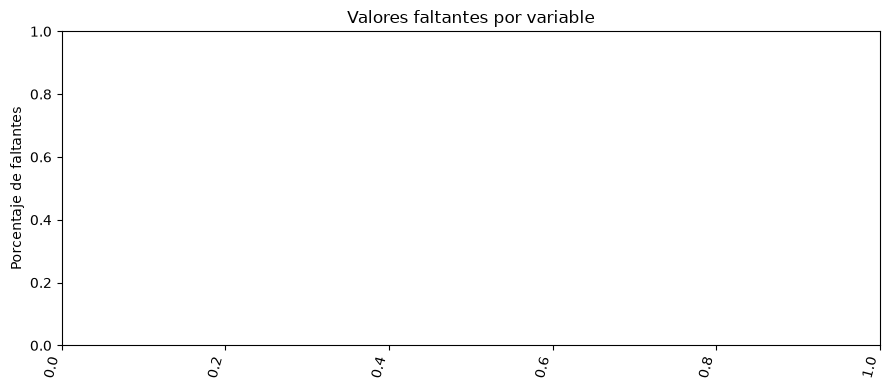

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(x=faltantes.index, y=faltantes["porcentaje"], color="#4C72B0")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Porcentaje de faltantes")
plt.title("Valores faltantes por variable")
plt.tight_layout()
plt.show()

No se evidencian faltantes.

<span style="font-size: 24px; font-weight: bold; color: #003366;">Outliers</span>

Para este análisis se seleccionaron 4 variables numéricas clave que concentran el mayor impacto operativo y financiero:
* Cantidad_días: Duración de la ausencia (se grafica en escala logarítmica para visualizar valores extremos s superiores).
* Remuneración_Mensual: Nivel salarial registrado del agente.
* Costo_Estimado_Ausencia: Variable calculada ($Sueldo / 30 \times Días$) que combina impacto de duración y salario.* Edad_Agente: Edad del agente al momento de iniciar la ausencia.

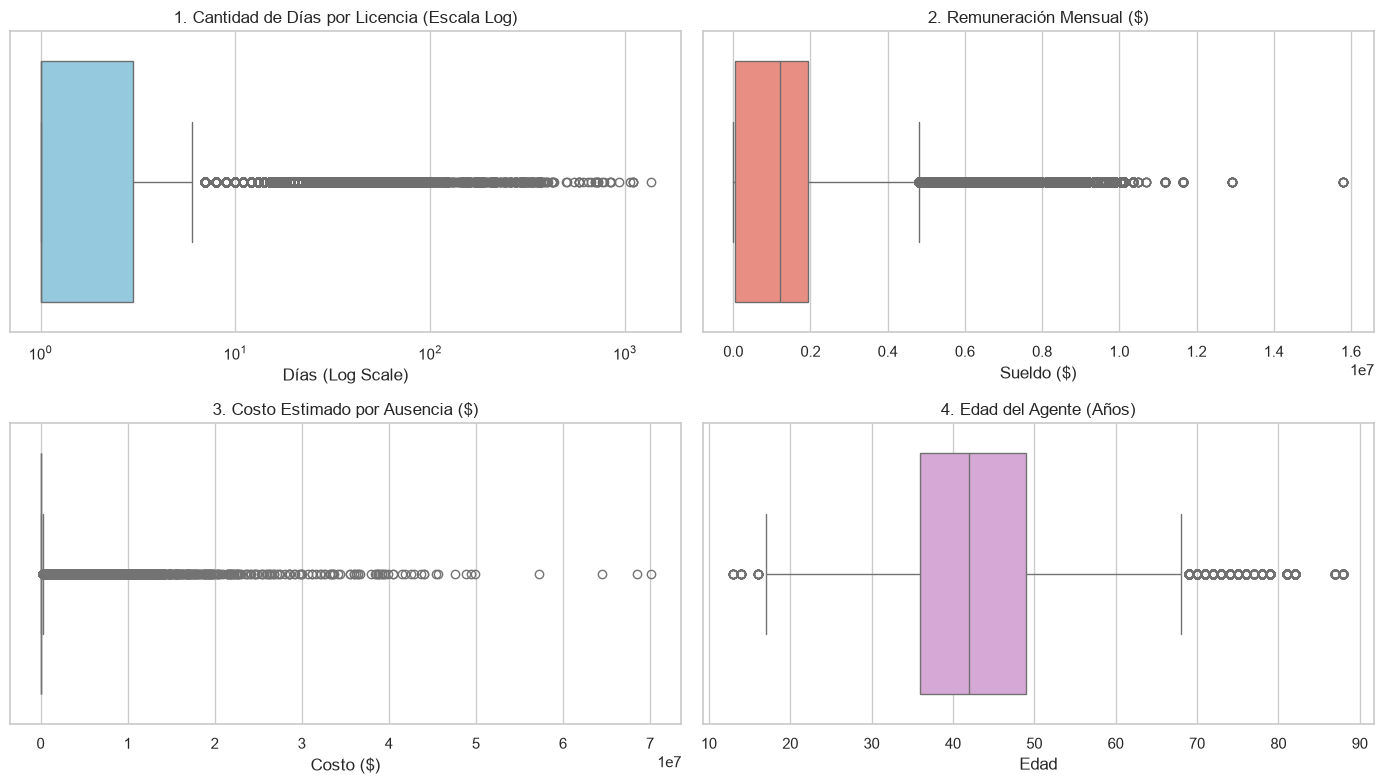

In [23]:

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Cantidad de Días (Escala Logarítmica)
sns.boxplot(x=df_ausentismo_ord['cantidad_dias'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_title("1. Cantidad de Días por Licencia (Escala Log)")
axes[0, 0].set_xlabel("Días (Log Scale)")

# 2. Remuneración Mensual
sns.boxplot(x=df_ausentismo_ord['Remuneración_Mensual_Clean'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("2. Remuneración Mensual ($)")
axes[0, 1].set_xlabel("Sueldo ($)")

# 3. Costo Estimado de Ausencia
sns.boxplot(x=df_ausentismo_ord['Costo_Estimado_Ausencia'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title("3. Costo Estimado por Ausencia ($)")
axes[1, 0].set_xlabel("Costo ($)")

# 4. Edad del Agente
sns.boxplot(x=df_ausentismo_ord['edad_agente'].dropna(), ax=axes[1, 1], color='plum')
axes[1, 1].set_title("4. Edad del Agente (Años)")
axes[1, 1].set_xlabel("Edad")


plt.tight_layout()
plt.show()

<span style="font-size: 20px; font-weight: bold; color: #003366;">Verificación del Dataset Transformado y Guardado</span>

In [ ]:
print("\nMatriz de variables final lista para modelos predictivos:")
print(df_ausentismo_ord.columns.tolist())

# Guardar el dataset resultante para modelado de Regresión / Clasificación
output_path = 'prueba2025_c_featured.csv'
df_ausentismo_ord.to_csv(output_path, index=False, encoding='utf-8')
print(f"\nDataset exportado exitosamente como '{output_path}'.")

Dataset procesado: 949,038 registros y 31 columnas.

Matriz de variables final lista para modelos predictivos:
['nro_legajo', 'escalafon', 'categoria', 'cod_art_ausencia', 'descripcion_articulo_ausencia', 'es_de_salud', 'fecha_desde', 'fecha_hasta', 'cantidad_dias', 'cant_dias_permitido_mes', 'cantidad_dias_permitido_año', 'dependencia', 'fecha_nacimiento', 'genero', 'antigüedad', 'remuneracion_mensual', 'edad_agente', 'mes_inicio', 'trimestre', 'dia_semana_inicio', 'es_fin_de_semana_adyacente', 'es_salud_num', 'dias_desde_ultima_ausencia', 'num_licencias_previas_agente', 'dias_ausencia_acumulados_año', 'tasa_uso_cupo_anual', 'Promedio_Dias_Dependencia', 'Promedio_Dias_Escalafon', 'Remuneración_Mensual_Clean', 'Costo_Diario_Agente', 'Costo_Estimado_Ausencia']

Dataset exportado exitosamente como 'prueba2025_c_featured.csv'.
